In [2]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import contextily as cx
import matplotlib.pyplot as plt
import pointpats
import numpy as np
import esda
import tobler
import pyinterpolate

from matplotlib import patches
from libpysal import graph
from scipy import interpolate
from sklearn import neighbors

In [29]:
skolky_body = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_body_validated7.parquet")
skolky_body

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600005399.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,http://www.ksidlisti.cz,"Škola Kavčí hory - Mateřská škola, Základní šk...",NaN,POINT (-743268.308 -1047032.287)
600025713.0,2.0,Kraj Vysočina,Třebíč,6113.0,www.spmstrebic.cz,Speciální mateřská škola Třebíč,NaN,POINT (-650746.181 -1153587.129)
600035140.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,www.msletenska.cz,Mateřská škola Letenská,1000.0,POINT (-744048.525 -1042979.657)
600035158.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,http://www.msmasna.cz,Mateřská škola Masná,NaN,POINT (-742975.837 -1043007.925)
600035174.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,www.msrevolucni.cz,Mateřská škola Revoluční,1140.0,POINT (-742655.357 -1043955.511)
...,...,...,...,...,...,...,...,...
691017166.0,2.0,Moravskoslezský kraj,Krnov,8114.0,https://www.msliptan.cz/,"Mateřská škola Liptaň, příspěvková organizace",NaN,POINT (-515723.822 -1054507.795)
691017379.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,www.zselektra.cz,"Základní škola a Mateřská škola Elektra, přísp...",1350.0,POINT (-736293.779 -1041437.02)
691017387.0,2.0,Ústecký kraj,Lovosice,4208.0,https://ms-sedmikraskavrbicany.webnode.cz/,Mateřská škola Sedmikráska Vrbičany - příspěvk...,1000.0,POINT (-760424.597 -998305.23)


In [30]:
skolky_body2 = skolky_body.loc[skolky_body["Zřizovate"] == 2]

In [31]:
skolky_body2["monthly_fe"] = skolky_body2["monthly_fe"].astype(float)

In [32]:
skolky_N_body = skolky_body2.loc[skolky_body2["monthly_fe"].isna()]
skolky_Z_body = skolky_body2.loc[skolky_body2["monthly_fe"].notna()]

<Axes: >

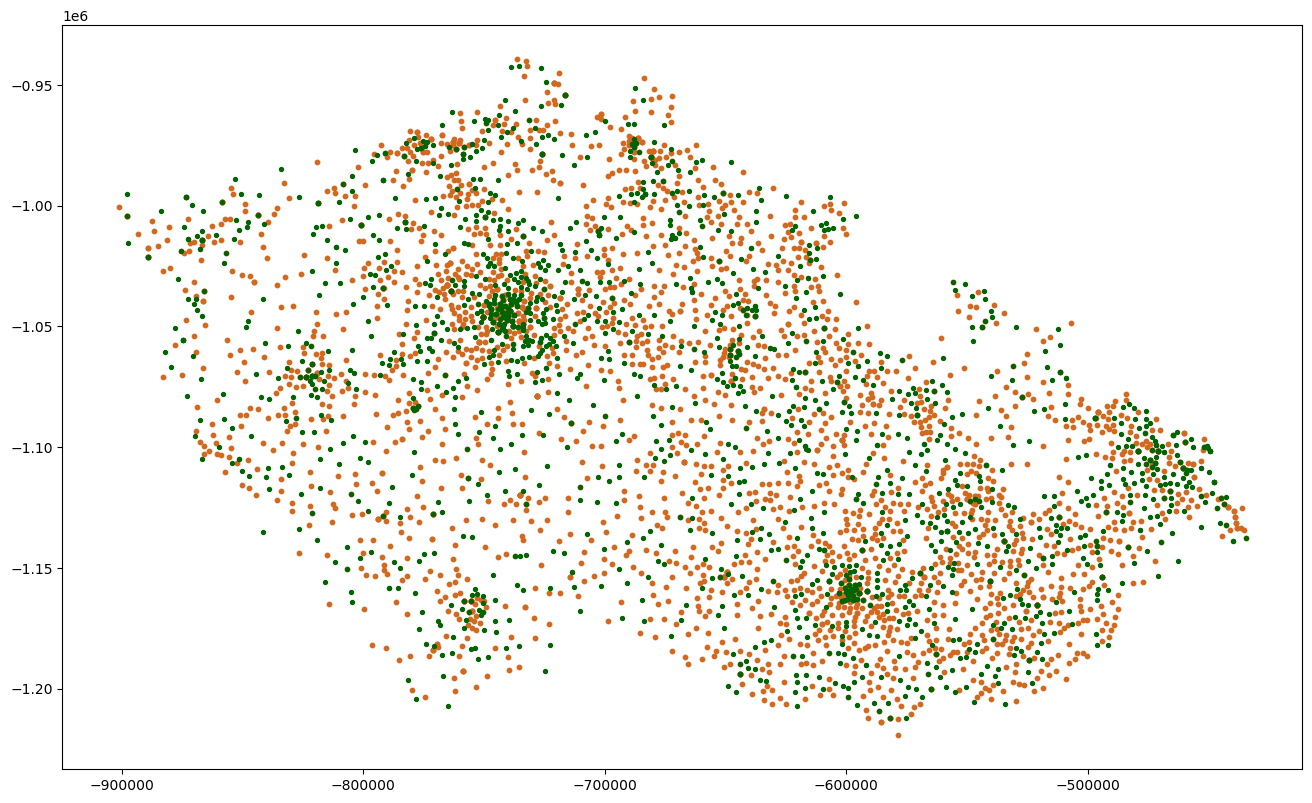

In [33]:
ax = skolky_N_body.plot(figsize=(16,10),markersize=10, color="chocolate")
skolky_Z_body.plot(markersize=8, color="darkgreen", ax=ax, )


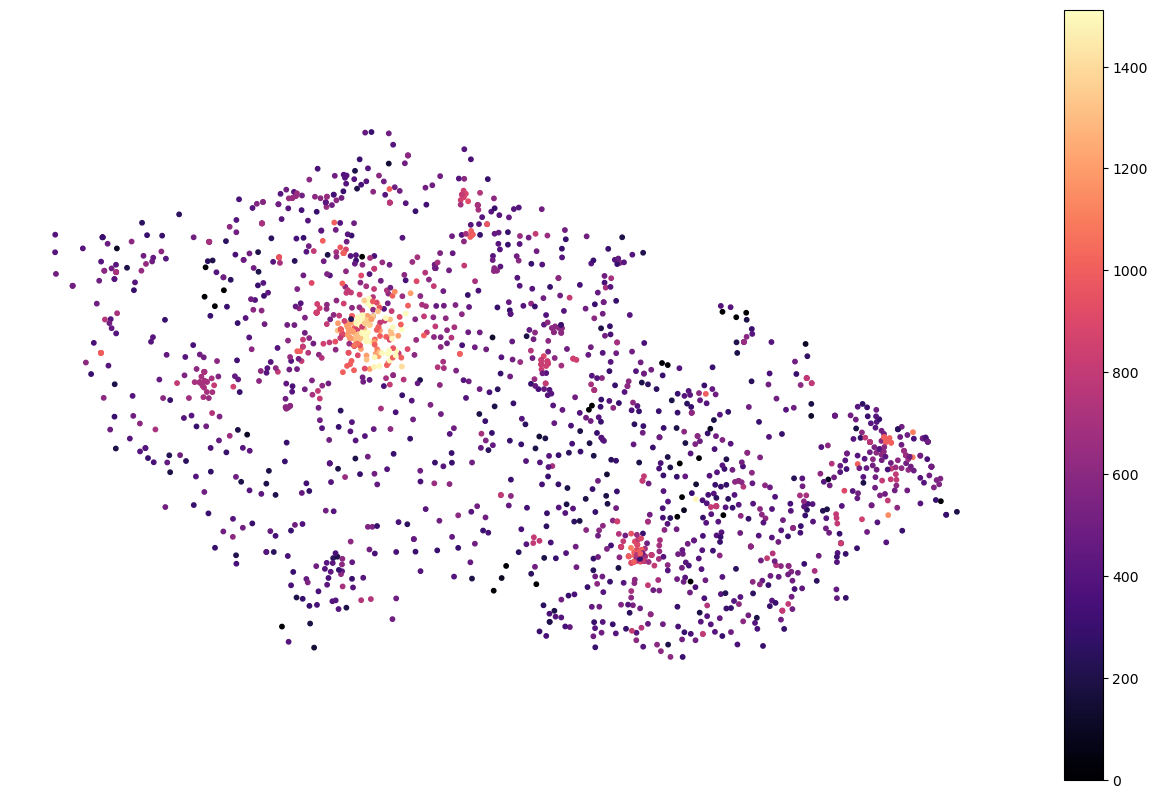

In [34]:
ax = skolky_Z_body.plot("monthly_fe", figsize=(16,10),markersize=10, cmap="magma", legend=True)
ax.set_axis_off()


In [35]:
k = [5,6,7,8,9, 10, 15,25, 50, 75, 100]
correlogram = esda.correlogram(
    geometry=skolky_Z_body,
    variable=skolky_Z_body["monthly_fe"],
    support=k,
    distance_type="knn",
)   

In [36]:
correlogram.I


5      0.742389
6      0.730572
7      0.722771
8      0.711732
9      0.706496
10     0.697424
15     0.682053
25     0.663828
50     0.637142
75     0.619890
100    0.601480
Name: I, dtype: float64

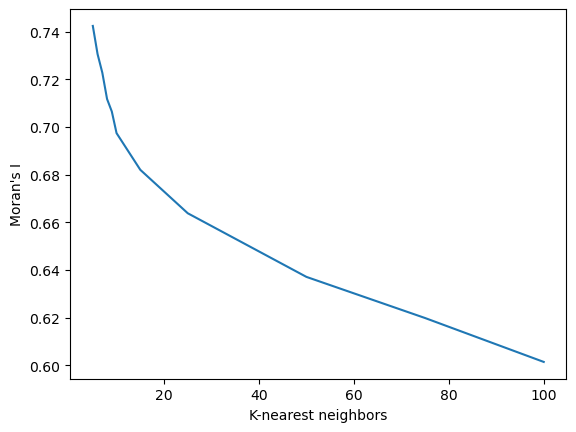

In [37]:
ax = correlogram.I.plot()
ax.set_xlabel("K-nearest neighbors")
_ = ax.set_ylabel("Moran's I")

In [38]:
knn10_kernel = graph.Graph.build_knn(skolky_Z_body, k=10,coplanar="jitter")
row_knn10_kernel = knn10_kernel.transform("r")


In [39]:
skolky_Z_body["fee_lag"] = row_knn10_kernel.lag(skolky_Z_body["monthly_fe"])


/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [40]:
skolky_Z_body["fee_std"] = (
    skolky_Z_body["monthly_fe"] - skolky_Z_body["monthly_fe"].mean()
) / skolky_Z_body["monthly_fe"].std()

/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [41]:
skolky_Z_body["fee_std_lag"] = row_knn10_kernel.lag(skolky_Z_body["fee_std"])


/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [42]:
# Vypočítej a ulož hodnotu Moranovo I pro "monthly_fe" se zadanou maticí prostorových vah.
mi = esda.Moran(skolky_Z_body["monthly_fe"], row_knn10_kernel)

# Vypiš zadaný text a hodnotu Moranova I a jeho p-hodnotu.
print("Moranovo I =",mi.I)
print("P-hodnota =",mi.p_sim)

Moranovo I = 0.697991628086421
P-hodnota = 0.001


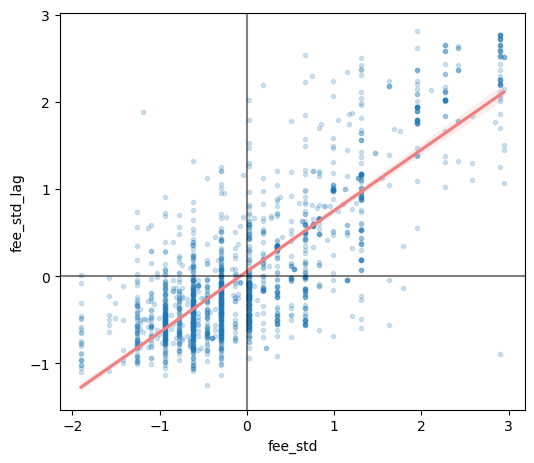

In [43]:
f, ax = plt.subplots(1, figsize=(6, 6))
sns.regplot(
    x="fee_std",
    y="fee_std_lag",
    data=skolky_Z_body,
    marker=".",
    scatter_kws={"alpha": 0.2},
    line_kws=dict(color="lightcoral")
)
ax.set_aspect('equal')
plt.axvline(0, c="black", alpha=0.5)
plt.axhline(0, c="black", alpha=0.5)


In [44]:
lisa = esda.Moran_Local(skolky_Z_body["monthly_fe"], row_knn10_kernel)


/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

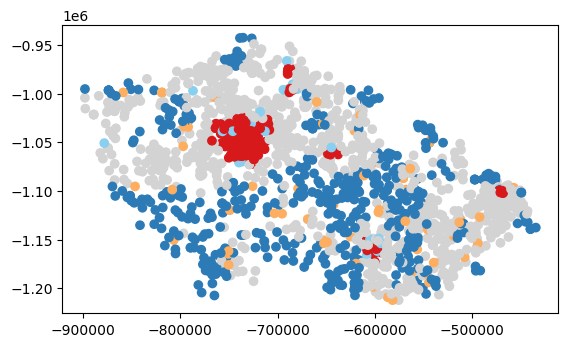

In [45]:
skolky_Z_body['cluster'] = lisa.get_cluster_labels(crit_value=0.05)
lisa.plot(
    skolky_Z_body,
    crit_value=0.05,
)